# Mini Project: Motor Execution vs Motor Imagery Analysis

This project uses the **eeg_pytorch** framework to analyze and classify EEG data from the PhysioNet Motor Imagery dataset.

We will compare two related datasets from the same subject:
1.  **Motor Execution**: Real movement of left/right fists.
2.  **Motor Imagery**: Imagined movement of left/right fists.

## Objectives
-   Download and load data using `eeg_pytorch`.
-   Analyze signal characteristics (PSD, Band Power).
-   Train a CNN model on both datasets.
-   Compare model performance.

In [ ]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset, random_split

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..')))

from eeg_pytorch.data.DataDownloader import DataDownloader
from eeg_pytorch.data.DataLoader import EEGDataset
from eeg_pytorch.models.CNN import CNN
from eeg_pytorch.analysis import features, visualization

%matplotlib inline

## 1. Data Acquisition

We download data for **Subject 1**.
-   **Execution Runs**: 3, 7, 11 (Left/Right Fist)
-   **Imagery Runs**: 4, 8, 12 (Imagine Left/Right Fist)

In [4]:
save_path = './eeg_data'
downloader = DataDownloader(save_path)

subject_ids = [1]
runs_exec = [3, 7, 11]
runs_imag = [4, 8, 12]

print("Downloading Execution Data...")
paths_exec = downloader.download_physionet_motor_imagery(subject_ids, runs_exec)

print("Downloading Imagery Data...")
paths_imag = downloader.download_physionet_motor_imagery(subject_ids, runs_imag)

## 2. Data Loading

We load the EDF files and resize them to 64x64 for the CNN.

In [5]:
print("Loading Execution Dataset...")
ds_exec = EEGDataset(data_path=paths_exec[1], file_type='edf', target_shape=(64, 64))

print("Loading Imagery Dataset...")
ds_imag = EEGDataset(data_path=paths_imag[1], file_type='edf', target_shape=(64, 64))

print(f"Execution Data: {ds_exec.data.shape}")
print(f"Imagery Data: {ds_imag.data.shape}")

Loading Execution Dataset...
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Loading Imagery Dataset...
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Execution Data: (90, 4096)
Imagery Data: (90, 4096)


## 3. Analysis & Visualization

Let's compare the raw signals and Power Spectral Density (PSD).

In [ ]:
# plot raw EEG
visualization.plot_raw_eeg(ds_exec.data[0].reshape(64, 64), fs=160, title="Motor Execution - Raw EEG")
visualization.plot_raw_eeg(ds_imag.data[0].reshape(64, 64), fs=160, title="Motor Imagery - Raw EEG")

/home/naman/anaconda3/envs/rbwd/lib/python3.9/site-packages/scipy/signal/_spectral_py.py:600: UserWarning: nperseg = 256 is greater than input length  = 64, using nperseg = 64
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


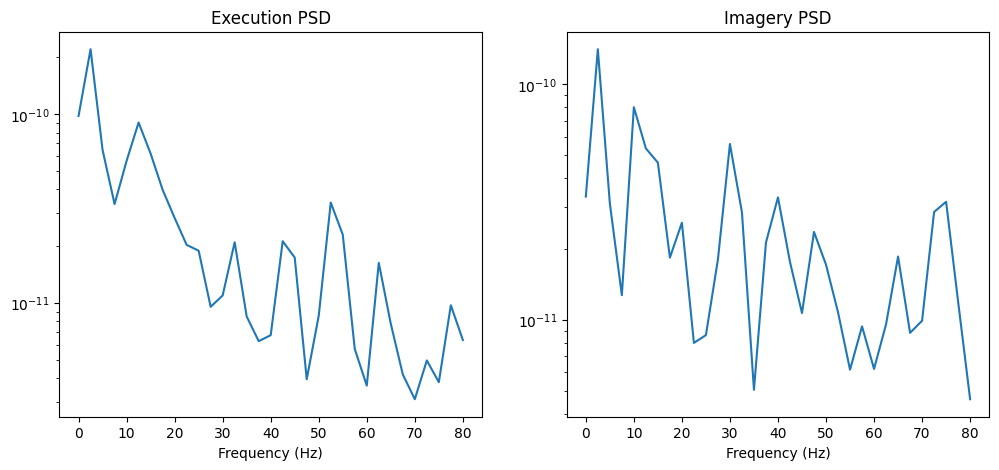

In [ ]:
# compute and plot PSD - postsynaptic density
freqs_exec, psd_exec = features.compute_psd(ds_exec.data[0].reshape(64, 64), fs=160)
freqs_imag, psd_imag = features.compute_psd(ds_imag.data[0].reshape(64, 64), fs=160)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.semilogy(freqs_exec, psd_exec.mean(axis=0))
plt.title("Execution PSD")
plt.xlabel("Frequency (Hz)")

plt.subplot(1, 2, 2)
plt.semilogy(freqs_imag, psd_imag.mean(axis=0))
plt.title("Imagery PSD")
plt.xlabel("Frequency (Hz)")
plt.show()

## 4. Model Training (CNN)

We will train a CNN on both datasets and compare the accuracy.

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def train_and_evaluate(dataset, name):
    print(f"\n--- Training on {name} ---")
    data = torch.from_numpy(dataset.data)
    labels = torch.from_numpy(dataset.labels)
    
    # PhysioNet annotations: T1=Left, T2=Right. MNE maps them to 0, 1, 2 (T0=Rest).
    # filter for T1 and T2 if needed, or just use all.
    # for simplicity, assume labels are valid or mod them
    if labels.max() >= 2:
        labels = labels % 2
        
    dataset_torch = TensorDataset(data, labels)
    train_size = int(0.8 * len(dataset_torch))
    test_size = len(dataset_torch) - train_size
    train_ds, test_ds = random_split(dataset_torch, [train_size, test_size])
    
    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, drop_last=True)
    test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, drop_last=True)
    
    model = CNN(num_classes=2).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    history = {'loss': [], 'acc': []}
    
    for epoch in range(10):
        model.train()
        total_loss = 0
        correct = 0
        total = 0
        
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
            
        acc = 100 * correct / total
        history['loss'].append(total_loss/len(train_loader))
        history['acc'].append(acc)
        print(f"Epoch {epoch+1}: Loss={total_loss/len(train_loader):.4f}, Acc={acc:.2f}%")
        
    visualization.plot_training_history(history, title=f"{name} Training")
    
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
            
    test_acc = 100 * correct / total
    print(f"{name} Test Accuracy: {test_acc:.2f}%")
    return test_acc

In [9]:
acc_exec = train_and_evaluate(ds_exec, "Motor Execution")
acc_imag = train_and_evaluate(ds_imag, "Motor Imagery")


--- Training on Motor Execution ---
Epoch 1: Loss=1.0993, Acc=48.44%
Epoch 2: Loss=0.7942, Acc=70.31%
Epoch 3: Loss=0.8695, Acc=68.75%
Epoch 4: Loss=1.1682, Acc=65.62%
Epoch 5: Loss=1.0011, Acc=71.88%
Epoch 6: Loss=1.1142, Acc=62.50%
Epoch 7: Loss=1.1228, Acc=64.06%
Epoch 8: Loss=0.8415, Acc=70.31%
Epoch 9: Loss=0.8282, Acc=67.19%
Epoch 10: Loss=0.7101, Acc=68.75%
Motor Execution Test Accuracy: 68.75%

--- Training on Motor Imagery ---
Epoch 1: Loss=0.6215, Acc=64.06%
Epoch 2: Loss=0.8910, Acc=60.94%
Epoch 3: Loss=1.1309, Acc=53.12%
Epoch 4: Loss=1.0262, Acc=62.50%
Epoch 5: Loss=0.9164, Acc=65.62%
Epoch 6: Loss=0.8494, Acc=73.44%
Epoch 7: Loss=1.1868, Acc=60.94%
Epoch 8: Loss=0.9688, Acc=70.31%
Epoch 9: Loss=0.5746, Acc=76.56%
Epoch 10: Loss=0.5671, Acc=79.69%
Motor Imagery Test Accuracy: 25.00%


## 5. Conclusion

We compared the performance of a CNN on real vs imagined movements.

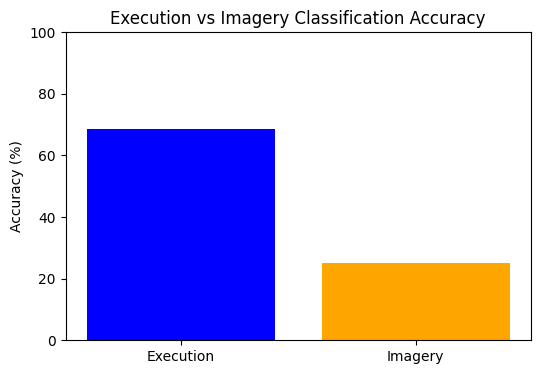

In [10]:
plt.figure(figsize=(6, 4))
plt.bar(['Execution', 'Imagery'], [acc_exec, acc_imag], color=['blue', 'orange'])
plt.ylabel("Accuracy (%)")
plt.title("Execution vs Imagery Classification Accuracy")
plt.ylim(0, 100)
plt.show()